# Spatial clusters
## Lecture objectives
1. Adapt the idea of k-means cluster analysis to spatial clusters
2. Provide more practice with k-means clustering and data wrangling

The principles of clustering that we discussed in the previous lecture apply to identify clusters in space. The difference: we just cluster on the `x` and `y` coordinates rather than non-spatial variables such as voting on a particular proposition.

Let's look at [clusters of marijuana dispensaries](https://data.lacity.org/Administration-Finance/Medical-Marijuana-Collective-Map/rv73-2zf4) in LA.

In [1]:
import pandas as pd
import requests
import json

url = 'https://data.lacity.org/resource/bunu-zsyc.json'
r = requests.get(url)
mdf = pd.DataFrame(json.loads(r.content))
mdf.head()

,location_account,business_name,street_address,city,zip_code,location_description,mailing_address,mailing_city,mailing_zip_code,naics,primary_naics_description,council_district,location_start_date,location_1,dba_name
0,0003207650-0001-1,"NORTHWEST CONFECTIONS CALIFORNIA, LLC",1538 S EASTERN AVENUE BUILDING,COMMERCE,90040-5614,1538 EASTERN 90040-5614,POST OFFICE BOX #456,CLACKAMAS,97015-0456,888888,Medical Marijuana Collective,0,2020-04-15T00:00:00.000,"{'type': 'Point', 'coordinates': [-118.1735, 3...",NaN
1,0003296729-0001-0,DOOBIEUS LLC,11618 PENDLETON STREET SUITE #2-4,SUN VALLEY,91352-2501,11618 PENDLETON 91352-2501,1401 21ST STREET SUITE #R,SACRAMENTO,95811-5226,888888,Medical Marijuana Collective,6,2023-05-01T00:00:00.000,NaN,DOOBIEUS LLC
2,0003166016-0001-1,LA ERUDITE VENTURES,850 S ROBERTSON BLVD FLOOR #1ST,LOS ANGELES,90035-1641,850 ROBERTSON 90035-1641,8863 GREENBACK LANE SPACE #328,ORANGEVALE,95662-4059,888888,Medical Marijuana Collective,5,2022-03-23T00:00:00.000,"{'type': 'Point', 'coordinates': [-118.3832, 3...",HERB N JOY
3,0003218985-0001-3,BONNET SHORES MANAGEMENT COMPANY LLC,5660 VENICE BLVD,LOS ANGELES,90019-5132,5660 Venice 90019-5132,5565 W END ROAD,ARCATA,95521-9244,888888,Medical Marijuana Collective,10,2023-03-28T00:00:00.000,"{'type': 'Point', 'coordinates': [-118.3616, 3...",NaN
4,0002220929-0001-3,CHINATOWN PATIENT COLLECTIVE GROUP INC,15223 BURBANK BLVD,VAN NUYS,91411-3505,15223 BURBANK 91411-3505,7250 NUNES LANE,EUREKA,95503-7193,888888,Medical Marijuana Collective,4,2007-01-30T00:00:00.000,"{'type': 'Point', 'coordinates': [-118.4648, 3...",COLLECTIVE GROUP CO


Note the lat /lon information is a dictionary in the `location_1` column.

In [2]:
mdf.location_1.iloc[0]

{'type': 'Point', 'coordinates': [-118.1735, 34.0118]}

<div class="alert alert-block alert-info">
    <strong>Exercise:</strong> Extract the lat/lon information from the <strong>location_1</strong> column and place it in two new columns
</div>

In [3]:
mdf['lat'] = mdf.location_1.apply(lambda x: float(x['coordinates'][1]))
mdf['lon'] = mdf.location_1.apply(lambda x: float(x['coordinates'][0]))

TypeError: 'float' object is not subscriptable

What row is causing this problem? Let's look at them?

In [4]:
mdf.location_1.head(20)

0     {'type': 'Point', 'coordinates': [-118.1735, 3...
1                                                   NaN
2     {'type': 'Point', 'coordinates': [-118.3832, 3...
3     {'type': 'Point', 'coordinates': [-118.3616, 3...
4     {'type': 'Point', 'coordinates': [-118.4648, 3...
5     {'type': 'Point', 'coordinates': [-118.3707, 3...
6                                                   NaN
7     {'type': 'Point', 'coordinates': [-122.2961, 3...
8     {'type': 'Point', 'coordinates': [-123.2379, 3...
9     {'type': 'Point', 'coordinates': [-118.2314, 3...
10                                                  NaN
11    {'type': 'Point', 'coordinates': [-118.4283, 3...
12    {'type': 'Point', 'coordinates': [-118.2624, 3...
13    {'type': 'Point', 'coordinates': [-118.464, 33...
14    {'type': 'Point', 'coordinates': [-118.2318, 3...
15    {'type': 'Point', 'coordinates': [-118.233, 34...
16    {'type': 'Point', 'coordinates': [-118.2334, 3...
17    {'type': 'Point', 'coordinates': [-118.453

OK, we need to drop the Null values for this column.

In [5]:
mdf.dropna(subset='location_1', inplace=True)
mdf['lat'] = mdf.location_1.apply(lambda x: float(x['coordinates'][1]))
mdf['lon'] = mdf.location_1.apply(lambda x: float(x['coordinates'][0]))

Let's have a look at the columns we just created. 

In [6]:
mdf[['lat','lon']].describe()

,lat,lon
count,728.000000,728.000000
mean,33.565050,-114.554415
std,4.369945,22.462014
min,0.000000,-124.071900
25%,34.018775,-118.439525
50%,34.060800,-118.347900
75%,34.202200,-118.252750
max,40.906800,34.318400


It looks like there are some errors in the input data. Some have a latitude and/or longitude of zero! There are also some with locations with improbable values.

Let's crudely limit the dataset to those in Los Angeles. I eyeballed the lat/lon limits from a map.

Then we can convert to a GeoDataFrame.

<Axes: >

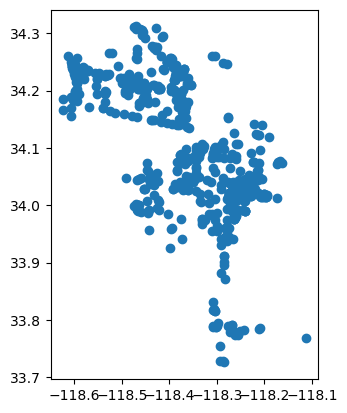

In [7]:
mdf = mdf[(mdf.lat>=33.6) & (mdf.lat<=34.8)]
mdf = mdf[(mdf.lon>=-119.0) & (mdf.lon<=-117.6)]

import geopandas as gpd

mgdf = gpd.GeoDataFrame(mdf, 
            geometry = gpd.points_from_xy(mdf.lon, mdf.lat), 
            crs='EPSG:4326')
mgdf.plot()

Now let's cluster. Again, we'd want to experiment with `K`, but let's identify 20 clusters to start.

Technically, we should reproject before we cluster because a degree of latitude is not the same distance as a degree of longitude. But we can overlook that for simplicity's sake.

In [8]:
from sklearn.cluster import KMeans

#以前kmeansを使った時と同じようにクラスターの数がいくつが妥当か、というのは、色々な数を当てはめてみるしかない
#色々な数を当てはめてみて、一番意味がありそうな数字を選ぶ

#lat, lonの1度あたりの距離は同じではないが、ここでは簡略化のために調整を省略
kmeans = KMeans(n_clusters=20, random_state=1).fit(mgdf[['lat','lon']])
mgdf['cluster_id'] = kmeans.labels_
mgdf.head()

,location_account,business_name,street_address,city,zip_code,location_description,mailing_address,mailing_city,mailing_zip_code,naics,primary_naics_description,council_district,location_start_date,location_1,dba_name,lat,lon,geometry,cluster_id
0,0003207650-0001-1,"NORTHWEST CONFECTIONS CALIFORNIA, LLC",1538 S EASTERN AVENUE BUILDING,COMMERCE,90040-5614,1538 EASTERN 90040-5614,POST OFFICE BOX #456,CLACKAMAS,97015-0456,888888,Medical Marijuana Collective,0,2020-04-15T00:00:00.000,"{'type': 'Point', 'coordinates': [-118.1735, 3...",NaN,34.0118,-118.1735,POINT (-118.1735 34.0118),0
2,0003166016-0001-1,LA ERUDITE VENTURES,850 S ROBERTSON BLVD FLOOR #1ST,LOS ANGELES,90035-1641,850 ROBERTSON 90035-1641,8863 GREENBACK LANE SPACE #328,ORANGEVALE,95662-4059,888888,Medical Marijuana Collective,5,2022-03-23T00:00:00.000,"{'type': 'Point', 'coordinates': [-118.3832, 3...",HERB N JOY,34.0615,-118.3832,POINT (-118.3832 34.0615),11
3,0003218985-0001-3,BONNET SHORES MANAGEMENT COMPANY LLC,5660 VENICE BLVD,LOS ANGELES,90019-5132,5660 Venice 90019-5132,5565 W END ROAD,ARCATA,95521-9244,888888,Medical Marijuana Collective,10,2023-03-28T00:00:00.000,"{'type': 'Point', 'coordinates': [-118.3616, 3...",NaN,34.0432,-118.3616,POINT (-118.3616 34.0432),11
4,0002220929-0001-3,CHINATOWN PATIENT COLLECTIVE GROUP INC,15223 BURBANK BLVD,VAN NUYS,91411-3505,15223 BURBANK 91411-3505,7250 NUNES LANE,EUREKA,95503-7193,888888,Medical Marijuana Collective,4,2007-01-30T00:00:00.000,"{'type': 'Point', 'coordinates': [-118.4648, 3...",COLLECTIVE GROUP CO,34.1724,-118.4648,POINT (-118.4648 34.1724),12
5,0003067479-0001-1,ASCELPIUS INCORPORATED,7127 VINELAND AVENUE UNIT #5,NORTH HOLLYWOOD,91605-6423,7127 VINELAND 91605-6423,1550 LEIGH AVENUE,SAN JOSE,95125-5301,888888,Medical Marijuana Collective,2,2018-01-01T00:00:00.000,"{'type': 'Point', 'coordinates': [-118.3707, 3...",STONEBREAKER,34.2002,-118.3707,POINT (-118.3707 34.2002),5


And map them! Again, this is almost identical code to what we used before. But let's ditch the legend because there are lots of clusters and the number is not as relevant.

[]

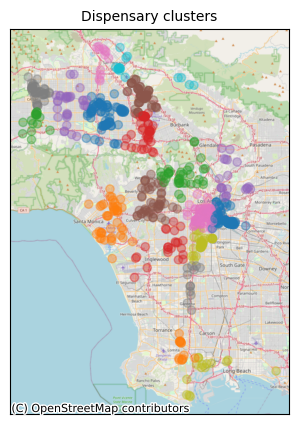

In [9]:
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(5,5))

#cluster IDはlegendとしてあまり重要ではないのでlegend=Falseと設定
mgdf.to_crs('EPSG:3857').plot('cluster_id', categorical=True, legend=False, 
                                   ax=ax, alpha=0.4)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title('Dispensary clusters', fontsize=10)                           
#ax.set_ylim([3.98e6, 4.14e6])
ax.set_xticks([])
ax.set_yticks([])

We could also map the centroid of each cluster. But I'll leave that for you as an exercise.

<div class="alert alert-block alert-info">
    <strong>Exercise:</strong> Map the centroid of each cluster. <em>Hint</em>: The raw lat/lon values are found in <strong>kmeans.cluster_centers_</strong>.
</div>

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
    <li>Spatial clusters work in a very similar way to non-spatial clusters.</li>
    <li>They can identify different groupings and/or hotspots.</li>

</ul>
</div>